In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np

tf.random.set_seed(42)


## Chargement du dataset fashion

In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt",
    "Pantalon",
    "Pull",
    "Robe",
    "Manteau",
    "Sandale",
    "Chemise",
    "Sneaker",
    "Sac",
    "Bottine",
]

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Train set: (60000, 28, 28)
Test set: (10000, 28, 28)


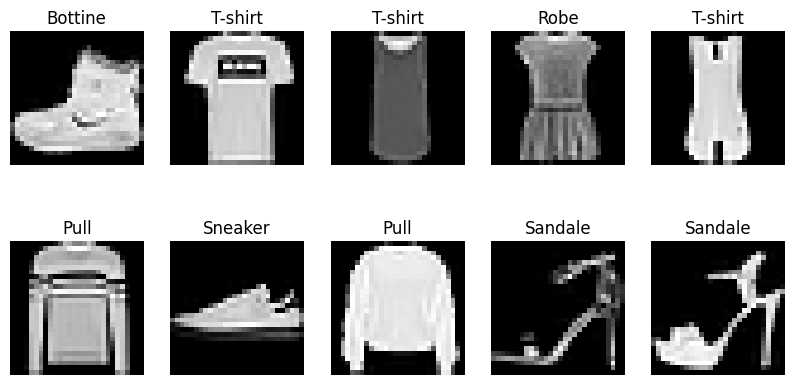

In [21]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"{class_names[y_train[i]]}")
    plt.axis("off")

## Preprocessing

In [22]:
print(f"Pixels values: [{X_train.min()}, {X_train.max()}]")

# Normalization: Divide pixels values by 255
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

# Flatten: (60_000, 28, 28) -> (60_000, 784)
_, w, h = X_train_norm.shape
X_train_flatten = X_train_norm.reshape(-1, w * h)
X_test_flatten = X_test_norm.reshape(-1, w * h)
print(f"Train set flatten: {X_train_flatten.shape}")
print(f"Test set flatten: {X_test_flatten.shape}")

# Encode labels: class9 -> [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
y_train_onehot = keras.utils.to_categorical(y_train, num_classes=10)
y_test_onehot = keras.utils.to_categorical(y_test, num_classes=10)

Pixels values: [0, 255]


Train set flatten: (60000, 784)
Test set flatten: (10000, 784)


## Création du modèle

In [23]:
model = keras.Sequential(
    [
        layers.Dense(128, activation="relu", input_shape=(w * h,), name="hidden_1"),
        layers.Dense(64, activation="relu", name="hidden_2"),
        layers.Dense(10, activation="softmax", name="output"),
    ],
    name="MLP_fashionMNIST",
)
model.summary()

c:\Users\Administrateur\Documents\M2i_CDSD_TDTP\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "MLP_fashionMNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Configuration des paramètres d'entraînement

In [24]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

In [25]:
history = model.fit(
    X_train_flatten,
    y_train_onehot,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1,
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8028 - loss: 0.5633 - val_accuracy: 0.8487 - val_loss: 0.4257
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8567 - loss: 0.3969 - val_accuracy: 0.8603 - val_loss: 0.3808
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8705 - loss: 0.3558 - val_accuracy: 0.8642 - val_loss: 0.3643
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8787 - loss: 0.3300 - val_accuracy: 0.8670 - val_loss: 0.3562
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8870 - loss: 0.3085 - val_accuracy: 0.8735 - val_loss: 0.3501
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8933 - loss: 0.2925 - val_accuracy: 0.8745 - val_loss: 0.3450
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8982 - loss: 0.2797 - val_accuracy: 0.8783 - val_loss: 0.3395
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9022 - loss: 0.2666 - val_accuracy: 0.

## Graphique Accuracy et Loss

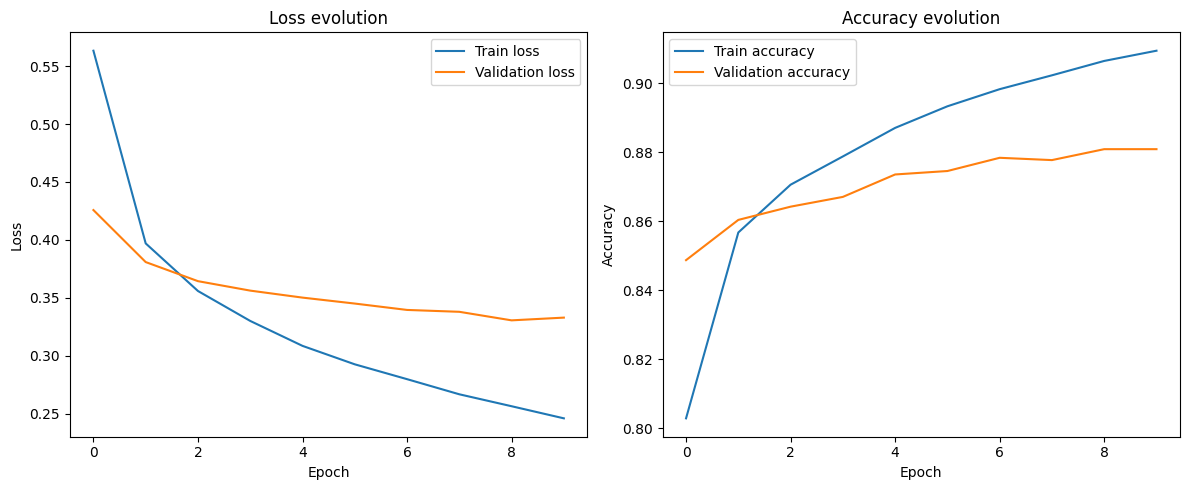

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Loss
ax1.plot(history.history["loss"], label="Train loss")
ax1.plot(history.history["val_loss"], label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss evolution")
ax1.legend()

# Accuracy
ax2.plot(history.history["accuracy"], label="Train accuracy")
ax2.plot(history.history["val_accuracy"], label="Validation accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy evolution")
ax2.legend()

plt.tight_layout()
plt.show()

## Evaluation sur le jeu de test

In [27]:
test_loss, test_accuracy = model.evaluate(X_test_flatten, y_test_onehot, verbose=1)

print(f"Test loss: {test_loss}")
print(f"Test accuracy: {test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 786us/step - accuracy: 0.8779 - loss: 0.3495
Test loss: 0.34954550862312317
Test accuracy: 0.8779000043869019


## Prédiction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


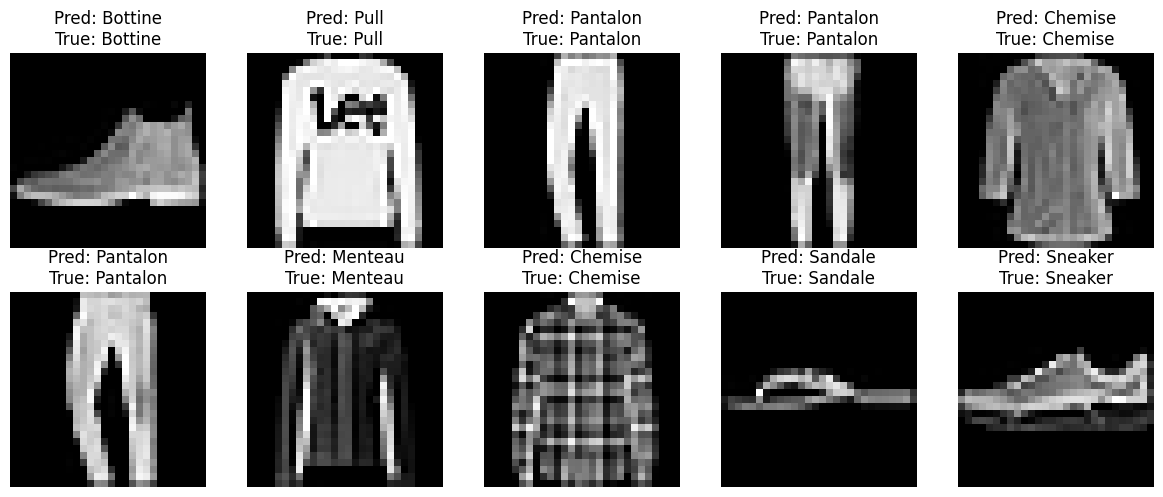

In [31]:
predictions = model.predict(X_test_flatten[:10])
predicted_classes = np.argmax(predictions, axis=1)

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title(
        f"Pred: {class_names[predicted_classes[i]]}\nTrue: {class_names[y_test[i]]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

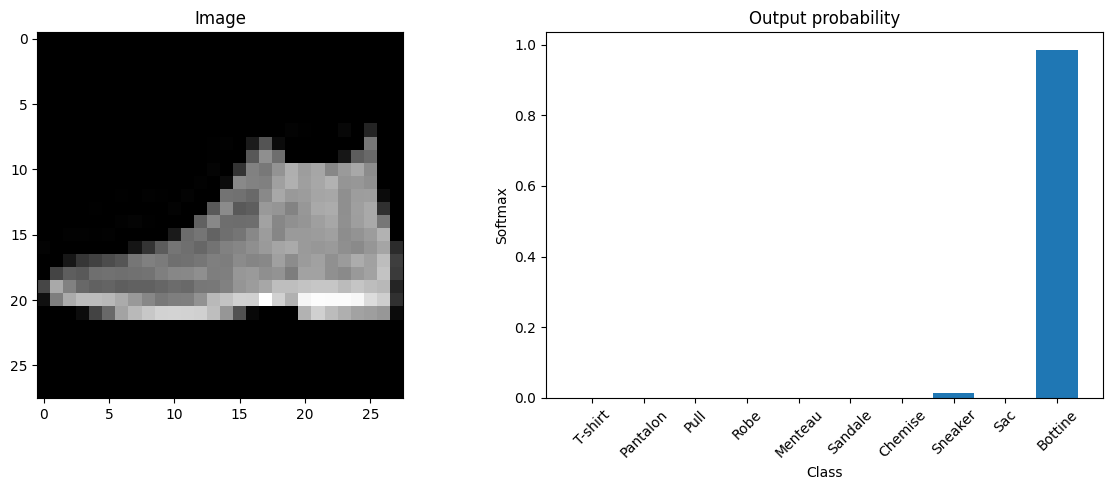

In [43]:
idx = 0
sample_prediction = predictions[idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.imshow(X_test[idx], cmap="gray")
ax1.set_title("Image")
ax1.axes == "off"

ax2.bar(range(10), sample_prediction)
ax2.set_xlabel("Class")
ax2.set_ylabel("Softmax")
ax2.set_title("Output probability")
ax2.set_xticks(range(10), class_names, rotation=45)

plt.tight_layout()
plt.show()

## Confusion matrix

In [54]:
y_pred = model.predict(X_test_flatten)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_onehot, axis=1)
cm = tf.math.confusion_matrix(y_true, y_pred_classes)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step


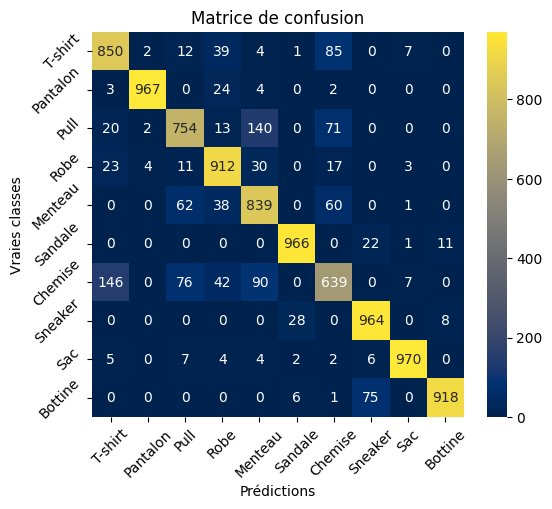

In [57]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="cividis")
plt.xlabel("Prédictions")
plt.ylabel("Vraies classes")
plt.xticks(np.arange(0.5, 10.5, 1), class_names, rotation=45)
plt.title("Matrice de confusion")
plt.yticks(np.arange(0.5, 10.5, 1), class_names, rotation=45)
plt.show()